# Task 1 — Iris Flower Classification

**Intern:** Aphile Ashley  
**Track:** Data Science · Oasis Infobyte (OIBSIP)  
**Status:** Sections 0–2 written; visualizations added, interpretation pending

> Sections are added in small groups. Nothing is marked complete until I have
> run it myself and can explain it.

## 0. Setup

- Imports
- Load the dataset with `sklearn.datasets.load_iris(as_frame=True)`
- Build a readable DataFrame with species names

**TODO (after running):** _write what I notice about the loaded data._

In [1]:
# --- Cell 0.1: imports -------------------------------------------------
# pandas   -> tables (DataFrames): rows and columns we can inspect/aggregate
# numpy    -> numbers and arrays (used indirectly by the other libraries)
# matplotlib -> the base plotting library; pyplot is its simple interface
# seaborn  -> built on matplotlib, makes statistical charts (pair/box plots)
# Path     -> build a task-local figures/ folder in a portable way
# load_iris -> ships the real Iris dataset inside scikit-learn (no download)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.datasets import load_iris

# %matplotlib inline shows plots directly under the cell when it runs.
%matplotlib inline

# A calm, readable default look for all the charts in this notebook.
sns.set_theme(style="whitegrid")

# Makes any random numbers in this notebook reproducible.
# We will set random_state explicitly on the train/test split later too.
RANDOM_STATE = 42

print("Libraries imported. pandas", pd.__version__)

Libraries imported. pandas 2.3.3


In [2]:
# --- Cell 0.2: load the real dataset -----------------------------------
# as_frame=True returns the data already as a pandas DataFrame (a table)
# instead of raw arrays. The table has our four measurements plus a
# 'target' column that holds the species as numbers 0, 1, 2.

iris = load_iris(as_frame=True)
iris_frame = iris.frame

iris_frame.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# --- Cell 0.3: readable DataFrame --------------------------------------
# The 'target' column is 0/1/2, which is hard to read in charts/tables.
# We map those numbers back to the real species names and store them in a
# new column called 'species'. The four measurement columns stay as they are.

df = iris_frame.copy()
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 1. Data inspection

- Shape
- Data types
- Null values
- Descriptive statistics
- Species counts

**TODO (my observation):** _write what I notice about the dataset._

In [4]:
# --- Cell 1.1: shape and data types ------------------------------------
# .shape gives (rows, columns). .dtypes tells us what kind of value each
# column holds (float64 = decimal numbers, category = a fixed set of labels).

print("Shape (rows, columns):", df.shape)
print()
print("Data types:")
print(df.dtypes)

Shape (rows, columns): (150, 6)

Data types:
sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
target                  int64
species              category
dtype: object


In [5]:
# --- Cell 1.2: missing values ------------------------------------------
# isnull() marks every empty cell; .sum() counts them per column.
# If every count is 0, there is nothing to clean before modelling.

print("Null counts per column:")
print(df.isnull().sum())
print()
print("Total nulls:", int(df.isnull().sum().sum()))

Null counts per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Total nulls: 0


In [6]:
# --- Cell 1.3: descriptive statistics ----------------------------------
# describe() summarises each numeric column: count, mean, std (spread),
# min, 25%/50%/75% quartiles and max. species is excluded because it is
# a label, not a number.

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
# --- Cell 1.4: species counts ------------------------------------------
# value_counts() shows how many rows belong to each species.
# A balanced dataset (equal counts) means accuracy will be a fair metric.

print("Rows per species:")
print(df["species"].value_counts())
print()
print("Proportions:")
print(df["species"].value_counts(normalize=True).round(3))

Rows per species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Proportions:
species
setosa        0.333
versicolor    0.333
virginica     0.333
Name: proportion, dtype: float64


## 2. Exploratory visualisation

Before plotting, I build `plot_df` from **only the four measurement columns
plus `species`**. The numeric `target` column is intentionally left out: it is
just the 0/1/2 codes for the same three species, so plotting it would duplicate
the label instead of adding a measurement.

**What to look for in the pair plot:** the diagonal shows each feature on its
own; the off-diagonal panels show one feature against another. I am looking for
groups of coloured points that sit apart from each other (separation) versus
groups that mix together (overlap).

**What to look for in the box plots:** the line inside each box is the median,
the box covers the middle 50% of values (the interquartile range), the whiskers
reach towards the extremes, and any separate dots are potential outliers.

> These charts are generated from the real Iris data when the cells run. I have
> left the interpretation for myself to write in the questions at the end of
> this section.

In [8]:
# --- Cell 2.1: build the plotting frame --------------------------------
# Only the four measurement columns plus 'species'. 'target' is deliberately
# excluded so no label code leaks into the features being visualised.

measurement_cols = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)",
]

plot_df = df[measurement_cols + ["species"]].copy()
print("Columns used for plotting:", list(plot_df.columns))
print("target column present?", "target" in plot_df.columns)
plot_df.head()

Columns used for plotting: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']
target column present? False


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Saved: figures/task1_pairplot.png


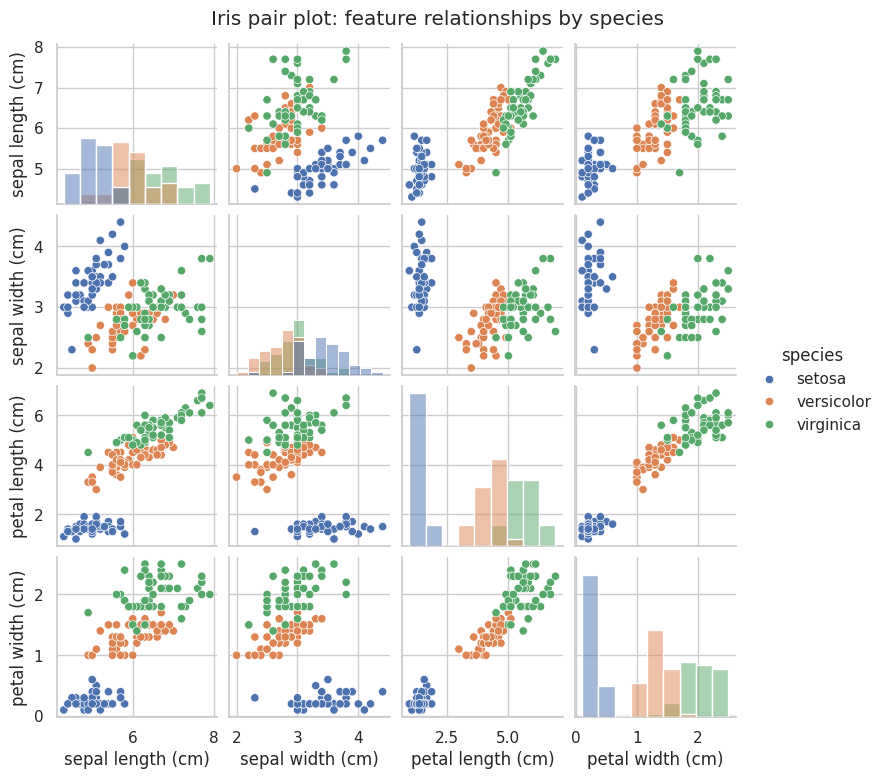

In [9]:
# --- Cell 2.2: pair plot coloured by species ----------------------------
# pairplot draws every measurement against every other measurement, with the
# species shown by colour, so separation and overlap are easy to compare.

figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

pair_grid = sns.pairplot(
    plot_df,
    hue="species",
    diag_kind="hist",
    height=1.9,
)
pair_grid.figure.suptitle(
    "Iris pair plot: feature relationships by species", y=1.02
)

pair_path = figures_dir / "task1_pairplot.png"
pair_grid.savefig(pair_path, dpi=150, bbox_inches="tight")
print("Saved:", pair_path)
plt.show()

Saved: figures/task1_boxplots.png


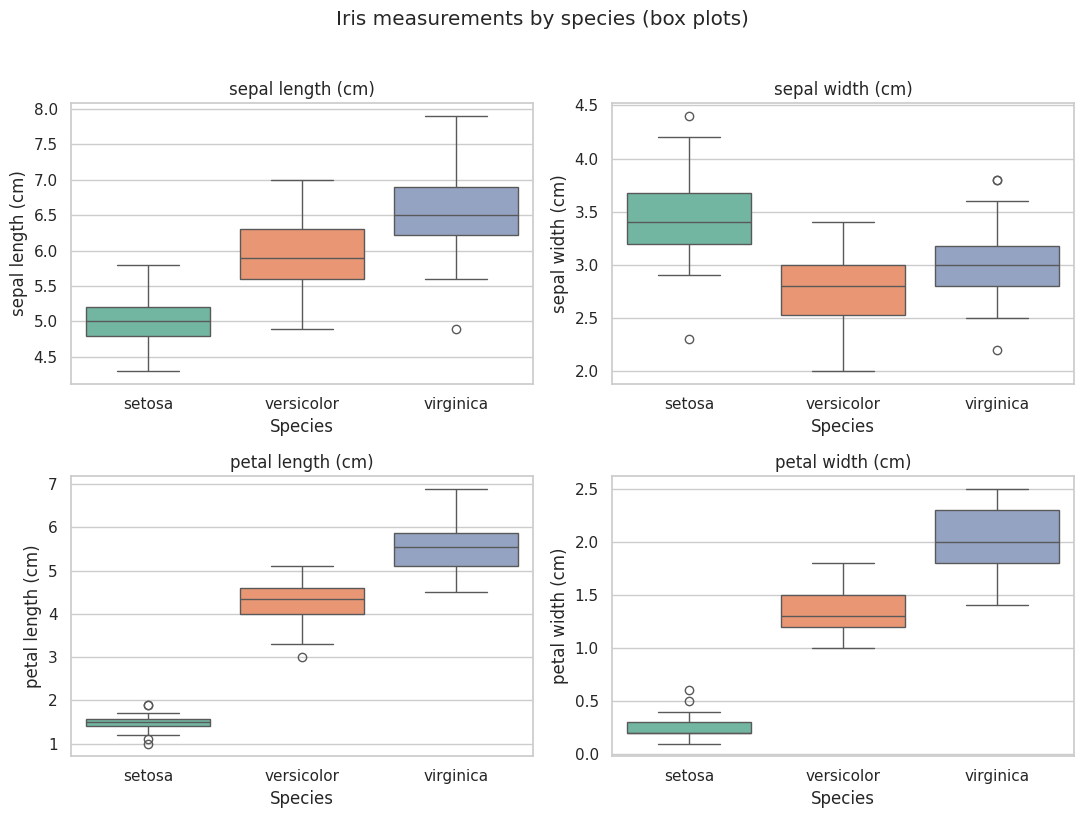

In [10]:
# --- Cell 2.3: box plots for each feature, grouped by species -----------
# Each panel is one measurement. Box = middle 50% (IQR), centre line = median,
# whiskers = spread, separate dots = potential outliers. The '(cm)' in each
# title and axis label is the unit.

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, col in zip(axes.ravel(), measurement_cols):
    sns.boxplot(
        data=plot_df,
        x="species",
        y=col,
        ax=ax,
        hue="species",
        palette="Set2",
        legend=False,
    )
    ax.set_title(col)
    ax.set_xlabel("Species")
    ax.set_ylabel(col)

fig.suptitle("Iris measurements by species (box plots)", y=1.02)
fig.tight_layout()

box_path = figures_dir / "task1_boxplots.png"
fig.savefig(box_path, dpi=150, bbox_inches="tight")
print("Saved:", box_path)
plt.show()

### Questions for me to answer in my own words

Answer these only after looking at the charts I just produced:

- [ ] **Clearest separation:** which of the four measurements separates the
  species most clearly in the pair plot? What exactly makes it look separate?
- [ ] **Overlap:** where do species still overlap, and which pairs are hardest
  to tell apart from the scatter panels alone?
- [ ] **Spread and outliers:** what do the box plots show about the spread of
  each feature, and do any species show potential outliers (dots outside the
  whiskers)? Which feature looks most compact per species?
- [ ] **So what:** based on the charts only, which measurements look most
  discriminative and which look least useful? I will state this in my own
  words — this is a question, not a finding.

## 3. Train/test split

- Reproducible ~80/20 split with `stratify=y` and a fixed `random_state`

**TODO (explain in my own words):** _what stratification changed about the
class distribution in train vs test._

## 4. Model training

- At least two classifiers (e.g. Logistic Regression, KNN / Decision Tree)
- Scaling inside a `Pipeline`, fit on training data only

**TODO:** _why scaling is needed for some of these models and not others._

## 5. Evaluation on the same held-out test set

- Accuracy
- Confusion matrix
- Precision, recall, F1 / classification report

**TODO (my interpretation):** _read every number in the classification
reports and say what it means for this problem._

## 6. Model selection

**TODO (my decision):** _which model I select based on the actual test
results above, and why — written only after seeing the numbers._

## 7. Conclusions and reflections

- **TODO:** key findings in my own words
- **TODO:** limitations of this analysis
- **TODO:** what I learned and what I would improve